# Training an SFNO on the Spherical Shallow Water Equations in Neuromancer

This notebook uses a Spherical Fourier Neural Operator (SFNO) from `neuralop` wrapped in a Neuromancer `Node`.

We will:
1. Load and visualize the spherical SWE dataset
2. Wrap the data in `neuromancer.dataset.DictDataset`
3. Train an SFNO with an L2 loss (`LpLoss` with sum reduction)
4. Evaluate and visualize predictions at multiple resolutions

Example inspiration: https://neuraloperator.github.io/dev/auto_examples/models/plot_SFNO_swe.html

References:

[1] [Bonev, Boris, et al. "Spherical fourier neural operators: Learning stable dynamics on the sphere." International conference on machine learning. PMLR, 2023.](https://arxiv.org/abs/2306.03838)

[2] [torch_harmonics Differentiable Shallow Water Equations example](https://github.com/NVIDIA/torch-harmonics/blob/main/notebooks/shallow_water_equations.ipynb)

[3] [NVIDIA blog: SFNO for Earth's atmosphere](https://developer.nvidia.com/blog/modeling-earths-atmosphere-with-spherical-fourier-neural-operators/)



## Problem Description – Spherical Shallow Water Equations (SWE)

The spherical shallow water equations (SWE) describe the evolution of a thin fluid layer on a rotating sphere $\mathbb{S}^2$.  
They describe large-scale atmospheric and oceanic flows where horizontal motion dominates and vertical structure is collapsed into a single layer.

The state of the system consists of:
- the geopotential (or layer depth) $\phi(\lambda,\varphi,t)$,
- the horizontal velocity field $\mathbf{u}(\lambda,\varphi,t)$, which is always tangent to the sphere.

Here, $\lambda$ denotes longitude and $\varphi$ latitude.

---

## Spherical SWE (standard rotating form)

The equations evolve entirely on the sphere using surface differential operators.

### Mass (height) equation
$$
\partial_t \phi
+
\nabla_{\mathbb{S}^2} \cdot (\phi \mathbf{u})
= 0
$$

### Momentum equation
$$
\partial_t \mathbf{u}
+
(\zeta + f)\,\mathbf{k} \times \mathbf{u}
+
\nabla_{\mathbb{S}^2}
\left(
\frac{1}{2}|\mathbf{u}|^2 + g\phi
\right)
= 0
$$

where:
- $\nabla_{\mathbb{S}^2}$ denotes gradient and divergence **on the sphere**,
- $\zeta = \mathbf{k}\cdot(\nabla_{\mathbb{S}^2}\times\mathbf{u})$ is the relative vorticity,
- $f = 2\Omega \sin\varphi$ is the Coriolis parameter,
- $\mathbf{k}$ is the outward unit normal to the sphere,
- $g$ is gravitational acceleration.

These equations account for spherical geometry, curvature effects, and planetary rotation.


## Operator-Learning Formulation

We learn an operator that maps the current SWE state on a spherical grid to the next state. The SFNO extends the Fourier Neural Operator to spherical harmonics, making it well suited for global geophysical data.

Let $u(\mathbf{x}, t)$ denote the SWE state on $\mathbb{S}^2$, represented by a 3-channel field, for example
$$
u = [\phi, \zeta, \delta],
$$
where $\phi$ is geopotential height, $\zeta$ is relative vorticity, and $\delta$ is horizontal divergence.

The learning task in this example is to approximate a discrete-time flow map:
$$
u^{n+1} = \mathcal{F}\!\left[u^n, t_n\right],
$$
where $u^n \approx u(\cdot, t_n)$ is the system state at time $t_n$.

<!-- For autoregressive forecasting, the learned operator is composed repeatedly:
$$
u^{n+s} \approx \mathcal{F}^{(s)}[u^n]
\;\equiv\;
\underbrace{\mathcal{F} \circ \cdots \circ \mathcal{F}}_{s \text{ times}}[u^n].
$$ -->


## SFNO Architecture (Why “Spherical”)

The Spherical Fourier Neural Operator (SFNO) replaces planar FFTs with spherical harmonic transforms (SHTs), ensuring that global spectral mixing respects the geometry and symmetries of the sphere.

A core SFNO spectral convolution layer takes the form:
$$
\mathcal{K}_\theta[u]
=
\mathcal{F}^{-1}
\!\left[
\tilde{\kappa}_\theta \cdot \mathcal{F}[u]
\right],
$$
where:
- $\mathcal{F}$ and $\mathcal{F}^{-1}$ denote the forward and inverse spherical harmonic transforms,
- $\tilde{\kappa}_\theta$ are learned spectral weights parameterized by spherical harmonic degree.

Stacking such layers with pointwise nonlinearities yields a neural operator that approximates the finite-time flow map of the spherical SWE.

## Install (Colab only)

Skip this step when running locally.


In [ ]:
# !pip install neuromancer
# !pip install neuralop

## Imports


In [ ]:
import warnings

import numpy as np
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


In [ ]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


## Numerical Data Generation (SFNO SWE Setup)

Training data are generated by sampling random initial conditions and evolving them with a classical spectral shallow-water solver on an equiangular latitude–longitude grid.

In the SFNO SWE experiments, the training data is generated using:
- Spatial resolution: $32 \times 64$,
- Time step: $\Delta t = 1200$ s,
- Time integration is delegated to the default of [torch_harmonics ShallowWaterSolver](https://github.com/NVIDIA/torch-harmonics/blob/main/torch_harmonics/examples/shallow_water_equations.py)
- Dependent variables: geopotential height $\phi$, vorticity $\zeta$, and divergence $\delta$. (The 3 channels)

The solver advances the system forward in time to produce supervised input–output pairs.

### Load the spherical shallow water dataset

We train on a low resolution to keep the example lightweight, then evaluate at multiple resolutions. A pre-defined `load_spherical_swe` function from `neuralop` is used to generate the datasets.


In [ ]:
from neuralop.data.datasets import load_spherical_swe

# Dataset configuration
n_train = 200
batch_size_train = 32
train_resolution = (32, 64)

n_tests = [40, 40]
test_resolutions = [(32, 64), (64, 128)]
test_batch_sizes = [40, 40]

train_loader, test_loaders = load_spherical_swe(
    n_train=n_train,
    batch_size=batch_size_train,
    train_resolution=train_resolution,
    test_resolutions=test_resolutions,
    n_tests=n_tests,
    test_batch_sizes=test_batch_sizes,
)

train_dataset = train_loader.dataset
print(f"Train dataset size: {len(train_dataset)}")


Loading train dataloader at resolution (32, 64) with 200 samples and batch-size=32
Loading test dataloader at resolution (32, 64) with 40 samples and batch-size=40
Loading test dataloader at resolution (64, 128) with 40 samples and batch-size=40
Train dataset size: 200


### Inspect dataset samples


In [ ]:
sample = train_dataset[0]
print(sample.keys())
print("x shape:", sample["x"].shape)
print("y shape:", sample["y"].shape)


dict_keys(['x', 'y'])
x shape: torch.Size([3, 32, 64])
y shape: torch.Size([3, 32, 64])


### Helper utilities for spherical SWE data


In [ ]:
def unpack_swe_sample(sample):
    # Return (x, y) as [C, H, W] tensors.
    x = sample["x"]
    y = sample["y"]
    if y.ndim == 4:
        y = y[0]
    if x.ndim == 4:
        x = x[0]
    return x.float(), y.float()


def stack_swe_dataset(dataset):
    # Stack the full dataset into [N, C, H, W] tensors.
    xs, ys = [], []
    for i in range(len(dataset)):
        x, y = unpack_swe_sample(dataset[i])
        xs.append(x)
        ys.append(y)
    return torch.stack(xs), torch.stack(ys)


def plot_swe_fields(x, y, title="Spherical SWE sample"):
    # Visualize input and target channels side by side.
    x = x.detach().cpu()
    y = y.detach().cpu()
    if x.ndim == 2:
        x = x.unsqueeze(0)
    if y.ndim == 2:
        y = y.unsqueeze(0)

    n_channels = min(x.shape[0], y.shape[0], 3)
    field_names = ["u", "v", "h"]

    fig = plt.figure(figsize=(4 * n_channels, 6))
    for i in range(n_channels):
        ax = fig.add_subplot(2, n_channels, i + 1)
        ax.imshow(x[i])
        ax.set_title(f"Input {field_names[i] if i < len(field_names) else f'ch{i}'}")
        ax.set_xticks([])
        ax.set_yticks([])

        ax = fig.add_subplot(2, n_channels, n_channels + i + 1)
        ax.imshow(y[i])
        ax.set_title(f"Target {field_names[i] if i < len(field_names) else f'ch{i}'}")
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(title, y=0.98)
    plt.tight_layout()
    plt.show()


def plot_prediction(x, y, y_pred, title, channel=0):
    # Plot a single channel prediction against ground truth.
    x = x.detach().cpu()
    y = y.detach().cpu()
    y_pred = y_pred.detach().cpu()

    if x.ndim == 2:
        x = x.unsqueeze(0)
    if y.ndim == 2:
        y = y.unsqueeze(0)
    if y_pred.ndim == 2:
        y_pred = y_pred.unsqueeze(0)

    u_true = y[channel].numpy()
    u_pred = y_pred[channel].numpy()
    denom = np.linalg.norm(u_true)
    rel_l2 = np.linalg.norm(u_true - u_pred) / denom if denom != 0 else float("nan")
    print(f"Relative L2 error (channel {channel}): {rel_l2:.4e}")

    vmin = u_true.min()
    vmax = u_true.max()

    fig = plt.figure(figsize=(12, 4))
    ax = fig.add_subplot(1, 3, 1)
    ax.imshow(x[channel])
    ax.set_title("Input")
    ax = fig.add_subplot(1, 3, 2)
    ax.imshow(y[channel], vmin=vmin, vmax=vmax)
    ax.set_title("Ground truth")
    ax = fig.add_subplot(1, 3, 3)
    ax.imshow(y_pred[channel], vmin=vmin, vmax=vmax)
    ax.set_title(f"SFNO prediction (rel L2: {rel_l2:.3e})")

    for ax in fig.axes:
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(title, y=0.98)
    plt.tight_layout()
    plt.show()


### Visualize a training sample


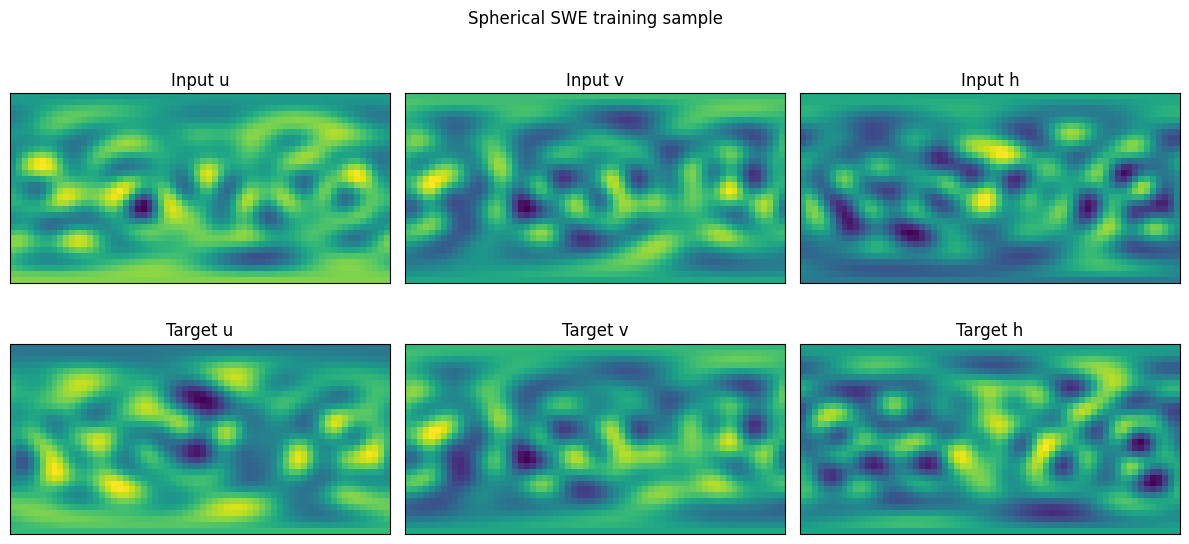

In [ ]:
vis_x, vis_y = unpack_swe_sample(train_dataset[0])
plot_swe_fields(vis_x, vis_y, title="Spherical SWE training sample")


### Create Neuromancer datasets for SFNO


In [ ]:
from torch.utils.data import DataLoader
from neuromancer.dataset import DictDataset

# Training data
x_train, y_train = stack_swe_dataset(train_dataset)
x_train = x_train.to(device)
y_train = y_train.to(device)

train_ds = DictDataset({"x_grid": x_train, "y_grid": y_train}, name="train")
train_loader_nm = DataLoader(
    train_ds,
    batch_size=batch_size_train,
    shuffle=True,
    collate_fn=train_ds.collate_fn,
)

# Testing data at multiple resolutions
test_ds_by_res = {}
for res in test_resolutions:
    test_dataset = test_loaders[res].dataset
    x_test, y_test = stack_swe_dataset(test_dataset)
    x_test = x_test.to(device)
    y_test = y_test.to(device)
    test_ds_by_res[res] = DictDataset(
        {"x_grid": x_test, "y_grid": y_test}, name=f"test_{res[0]}x{res[1]}"
    )


### Dimensionality checks


In [ ]:
print("Train x:", train_ds.datadict["x_grid"].shape)
print("Train y:", train_ds.datadict["y_grid"].shape)
for res, ds in test_ds_by_res.items():
    print(f"Test {res} x:", ds.datadict["x_grid"].shape)
    print(f"Test {res} y:", ds.datadict["y_grid"].shape)


Train x: torch.Size([200, 3, 32, 64])
Train y: torch.Size([200, 3, 32, 64])
Test (32, 64) x: torch.Size([40, 3, 32, 64])
Test (32, 64) y: torch.Size([40, 3, 32, 64])
Test (64, 128) x: torch.Size([40, 3, 64, 128])
Test (64, 128) y: torch.Size([40, 3, 64, 128])


### Create the SFNO model


In [ ]:
from neuromancer.modules.operators import SFNO
from neuralop.utils import count_model_params

in_channels = x_train.shape[1]
out_channels = y_train.shape[1]
n_modes = (train_resolution[0] // 2, train_resolution[1] // 2)

sfno_model = SFNO(
    n_modes=n_modes,
    in_channels=in_channels,
    out_channels=out_channels,
    hidden_channels=64,
    domain_padding=[0.05, 0.05],
    n_layers=2,
).to(device)

n_params = count_model_params(sfno_model)
print(f"Our model has {n_params} parameters.")


Our model has 296707 parameters.


### Wrap SFNO in a Neuromancer Node


In [ ]:
from neuromancer.system import Node

sfno_node = Node(sfno_model, ["x_grid"], ["y_hat"], name="sfno_model")
print("symbolic inputs:", sfno_node.input_keys)
print("symbolic outputs:", sfno_node.output_keys)

# Forward pass sanity check
with torch.no_grad():
    sample_out = sfno_node({"x_grid": x_train[:1]})
print("SFNO output shape:", sample_out["y_hat"].shape)


symbolic inputs: ['x_grid']
symbolic outputs: ['y_hat']
SFNO output shape: torch.Size([1, 3, 32, 64])


### L2 loss and Neuromancer problem


In [ ]:
from neuromancer.constraint import Loss
from neuromancer.modules.operators import LpLoss

# L2 loss with sum reduction for spherical data
l2loss = LpLoss(d=2, p=2, reduction="sum")

l2_obj = Loss(
    ["y_hat", "y_grid"],
    lambda yhat, y: l2loss(yhat, y),
    name="l2_loss",
)

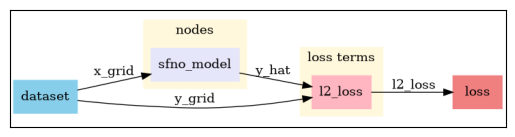

In [ ]:
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem

loss = PenaltyLoss([l2_obj], [])
problem = Problem(nodes=[sfno_node], loss=loss)
# problem.show()

### Train the SFNO (Neuromancer Trainer)


In [ ]:
from neuromancer.trainer import Trainer

optimizer = torch.optim.AdamW(problem.parameters(), lr=5e-3, weight_decay=1e-4)
epochs = 100

trainer = Trainer(
    problem.to(device),
    train_loader_nm,
    optimizer=optimizer,
    epochs=epochs,
    epoch_verbose=5,
    train_metric="train_loss",
    dev_metric="train_loss",
    eval_metric="train_loss",
    warmup=epochs,
    device=device,
)

best_model = trainer.train()
problem.load_state_dict(best_model)


epoch: 0  train_loss: 0.7507240176200867
epoch: 5  train_loss: 0.26715052127838135
epoch: 10  train_loss: 0.1920524388551712
epoch: 15  train_loss: 0.15459787845611572
epoch: 20  train_loss: 0.12375575304031372
epoch: 25  train_loss: 0.1097889393568039
epoch: 30  train_loss: 0.09441495686769485
epoch: 35  train_loss: 0.08924294263124466
epoch: 40  train_loss: 0.08329175412654877
epoch: 45  train_loss: 0.07928574085235596
epoch: 50  train_loss: 0.0707399770617485
epoch: 55  train_loss: 0.07104728370904922
epoch: 60  train_loss: 0.06615372002124786
epoch: 65  train_loss: 0.0621112622320652
epoch: 70  train_loss: 0.06421899795532227
epoch: 75  train_loss: 0.05840538069605827
epoch: 80  train_loss: 0.057623524218797684
epoch: 85  train_loss: 0.05826960504055023
epoch: 90  train_loss: 0.05570705607533455
epoch: 95  train_loss: 0.053978003561496735


<All keys matched successfully>

### Visualize SFNO predictions


Relative L2 error (channel 0): 3.3074e-01


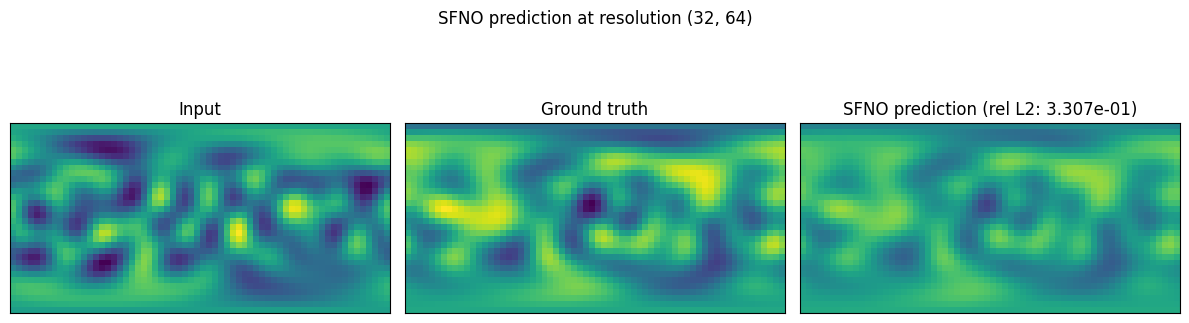

Relative L2 error (channel 0): 1.0602e+00


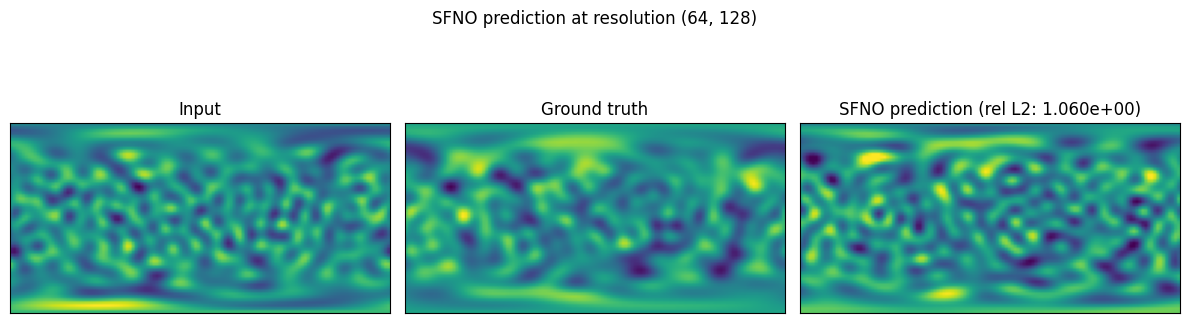

In [ ]:
sfno_eval = problem.nodes[0].to(device)

for res, test_ds in test_ds_by_res.items():
    x_test = test_ds.datadict["x_grid"]
    y_test = test_ds.datadict["y_grid"]
    with torch.no_grad():
        preds = sfno_eval({"x_grid": x_test})["y_hat"]
    plot_prediction(
        x_test[0],
        y_test[0],
        preds[0],
        title=f"SFNO prediction at resolution {res}",
        channel=0,
    )
